<h1>VQE for the Heisenberg Model</h1>

Simulating quantum systems is one of the main applications proposed for current and near-term quantum computers. Hybrid classical-quantum approaches, such as Variational Quantum Algorithms (VQAs), are promising candidates for this in the current Noisy Intermediate Scale Quantum, or NISQ, era. This hybrid approach involves running a quantum circuit on a quantum processing unit (QPU), while doing the optimisation of circuit parameters classically.

<h2> The Heisenberg Model </h2>

The Heisenberg model is an important model used to study the properties of magnetic systems. In the model, microscopic magnetic dipole moments in the system are modeled as spins on lattice sites, which can point in two directions: up or down. Simulating such a quantum system is a difficult task for classical computers, and one where quantum computers may show advantage over classical methods.
The Heisenberg model is described by a Hamiltonian defined as
$$\hat{H} = -J\sum_{j=1}^N\big{(}{\sigma}_j^x{\sigma}_{j+1}^x+{\sigma}_j^y{\sigma}_{j+1}^y+{\sigma}_j^z{\sigma}_{j+1}^z\big{)} - h\sum_{j=1}^N\sigma_j^z,$$
where $\sigma_j$ are Pauli matrices representing the spins in the spin chain, $J$ is the coupling constant describing the strength of the interaction between the spins, and $h$ is the strength of an external magnetic field. In the absence of an applied magnetic field, $h = 0$, and the Hamiltonian reduces to
$$\hat{H} = -J\sum_{j=1}^N\big{(}{\sigma}_j^x{\sigma}_{j+1}^x+{\sigma}_j^y{\sigma}_{j+1}^y+{\sigma}_j^z{\sigma}_{j+1}^z\big{)}.$$

In this case, the model is fully characterised by the exchange interaction $J$ between the spins in the system. The spin alignment of such a system is determined by which alignment is the most energetically favorable, resulting in the lowest energy.

For $J > 0$: spins prefer to align with each other $\rightarrow$ ferromagnetic<br>
For $J < 0$: spins prefer to point in opposite directions $\rightarrow$ antiferromagnetic [1].

<h2>Variational Quantum Eigensolver (VQE)</h2>

Variational Quantum Algorithms (VQAs) are a type of hybrid quantum-classical algorithm designed to work with the currently available noisy quantum computers. In a VQA, a parametrized quantum circuit is executed on a quantum computer and the circuit parameters are optimized classically with the goal of minimizing a cost function [2].

Variational Quantum Eigensolvers are a type of variational quantum algorithm designed for the purpose of finding the ground state of a quantum system or molecule. In a VQE, the cost function to be minimized in the classical optimization loop is the energy of the system given by the expectation value of the Hamiltonian, which once minimized gives the ground state energy of the system:

$$ E_0 = \text{min}_\theta⟨\psi(\theta)|H|\psi(\theta)⟩, $$

where $|\psi(\theta)⟩$ is the quantum state prepared by the parametrised circuit. By iteratively updating $\theta$
with a classical optimizer, the algorithm converges toward the ground state energy [2]. 

In this notebook, we implement VQE for the Heisenberg model.

<h2>Heisenberg model VQE</h2>

<h3> Importing libraries </h3>

In [ ]:
# For visualization and other useful tools
import matplotlib.pyplot as plt
%matplotlib inline
from qiskit.visualization import plot_histogram
import numpy as np
from typing import List

# For the quantum part
from qiskit import QuantumCircuit
from qiskit.circuit.library import EfficientSU2
from qiskit.quantum_info import SparsePauliOp, pauli_basis, Operator
from qiskit.primitives import StatevectorEstimator
from qiskit_ibm_runtime import Estimator, Session, Options
from qiskit.compiler import transpile

# For classical optimization
""" importing optimization part from a separate file: learning_algorithm.py
    (or learning_algorithm_REM.py for readout error mitigation but initial layout needs to be selected in that file)"""
import sys
import os

sys.path.append(os.path.abspath("../LearningAlgorithm"))

from LearningAlgorithm.learning_algorithm import Learning

# For backend
from iqm import qiskit_iqm
from iqm.qiskit_iqm.fake_backends import fake_aphrodite
from iqm.qiskit_iqm import IQMProvider
from qiskit_aer import AerSimulator

<h3>Setting backend</h3>

In [2]:
# UNCOMMENT YOUR CHOICE OF BACKEND

backend = AerSimulator()                          # fake backend without noise
#backend = fake_aphrodite.IQMFakeAphrodite()      # fake Q50
target = backend.target

# Helmi (VTT Q5) 5-qubit quantum computer (requires access)
HELMI_CORTEX_URL = os.getenv('HELMI_CORTEX_URL')
# provider = IQMProvider(HELMI_CORTEX_URL)
# backend = provider.get_backend()

# Q50 (VTT Q50) 52-qubit quantum computer (requires access)
Q50_CORTEX_URL = os.getenv('Q50_CORTEX_URL')
# provider_q50 = IQMProvider(Q50_CORTEX_URL)
# backend = provider_q50.get_backend()

<h3>Setting model parameters</h3>

In [3]:
n = 4         # number of spins/qubits
J = 1.0       # coupling constant

<h3>Defining Hamiltonian</h3>

In [4]:
def heisenberg_sparse_pauli_op(n_qubits, J):
    paulis = []
    coeffs = []
    
    for i in range(n_qubits - 1):
        for pauli in ['XX', 'YY', 'ZZ']:
            label = ['I'] * n_qubits
            label[i] = pauli[0]
            label[i+1] = pauli[1]
            paulis.append(''.join(label))
            coeffs.append(-J)
    
    return SparsePauliOp(paulis, coeffs=np.array(coeffs, dtype=float))

heisenberg_hamiltonian = heisenberg_sparse_pauli_op(n, J)

<h3>Parametrised quantum circuit</h3>

Defining the ansatz and printing it: 

Ansatz:
Number of parameters: 16
Total number of gates 22
Figure(872.774x367.889)


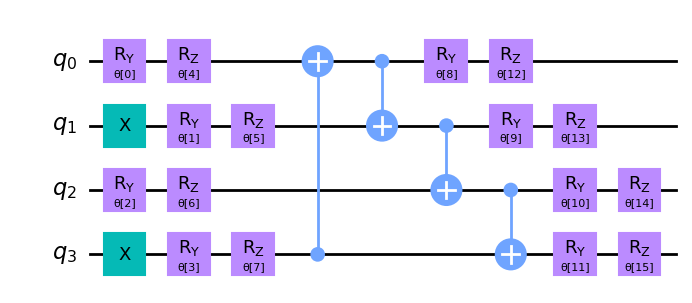

In [5]:
def ansatz_function(n, J):

    SU2_ansatz = EfficientSU2(n, reps=1, entanglement="circular")
    
    # For positive J -> initial state for antiferromagnetic order
    if J > 0:
        def create_neel_state(num_qubits):
            qc = QuantumCircuit(num_qubits)
            for qubit in range(num_qubits):
                if qubit % 2 == 1:
                    qc.x(qubit)
            return qc
        # initial Neel state |010101...>
        neel_state = create_neel_state(n)
        ansatz = neel_state.compose(SU2_ansatz)
    # For negative J -> initial state for ferromagnetic order
    elif J < 0:
        # initial superposition state |0000...> + |1111...>
        ferro_initial = QuantumCircuit(n)
        ferro_initial.h(range(n)) 
        ansatz = ferro_initial.compose(SU2_ansatz)
    return ansatz

circuit = ansatz_function(n, J)

# Transpiling the circuit
circuit_transpiled = transpile(circuit, target=backend.target, layout_method="trivial", routing_method = "sabre", optimization_level=3)

# Removing unused qubits
# (estimator requires same qubit number for observable and circuit, IQM backends add idle qubits during transpilation)
def remove_unused_qubits(circuit: QuantumCircuit) -> QuantumCircuit:
    # Identify used qubits
    used_qubits = set()
    for instr, qargs, _ in circuit.data:
        for qubit in qargs:
            used_qubits.add(qubit)

    # Map old qubits to new indices
    qubit_map = {qubit: idx for idx, qubit in enumerate(sorted(used_qubits, key=lambda q: circuit.qubits.index(q)))}
    new_circ = QuantumCircuit(len(used_qubits))

    # Rebuild the circuit
    for instr, qargs, cargs in circuit.data:
        new_qargs = [new_circ.qubits[qubit_map[q]] for q in qargs]
        new_circ.append(instr, new_qargs, cargs)

    return new_circ

ansatz = remove_unused_qubits(circuit_transpiled)

print("Ansatz:")
print("Number of parameters:", ansatz.num_parameters)
print("Total number of gates", len(ansatz))
print(ansatz.draw('mpl', style="clifford"))

<h3>Classical optimization</h3>

For conciseness, the classical optimization loop has been imported from a separate file _learning_algorithm.py_. The classical optimizer can be selected here, but other changes to optimizer settings or adding new optimizer options can be done by editing _learning_algorithm.py_.

In [6]:
# Matching Hamiltonian and circuit dimensions (required by estimator)
def pad_hamiltonian(ham: SparsePauliOp, total_qubits: int) -> SparsePauliOp:
    current_qubits = ham.num_qubits
    if current_qubits == total_qubits:
        return ham
    elif current_qubits > total_qubits:
        raise ValueError("Hamiltonian has more qubits than the circuit.")

    # Pad with identities on the left (least significant qubits)
    n_pad = total_qubits - current_qubits
    padding = SparsePauliOp.from_list([('I' * n_pad, 1.0)])
    padded_ham = ham.tensor(padding)
    return padded_ham

hamiltonian = pad_hamiltonian(heisenberg_hamiltonian, ansatz.num_qubits)

"""Choosing optimizer (options include: "BFGS", "SPSA", "basinhopping", "dual_annealing", "cobyla", and "gp_minimize")
SPSA is recommended for running on real QPU (most tolerant against noise and uses only 2 circuit runs per iteration)"""
optimizer = "cobyla"
#estimator = StatevectorEstimator()         # can be used with simulators only
estimator = Estimator(mode=backend)         # can be used with simulators and with real QPUs

# Running optimization loop
learning = Learning(ansatz, hamiltonian, backend, estimator, optimizer)
result = learning.run()
energy_achieved = learning.cost


Iterations: 1 | Current cost: 1.0439453125

Iterations: 2 | Current cost: 0.943359375

Iterations: 3 | Current cost: 0.59521484375

Iterations: 4 | Current cost: -1.79052734375

Iterations: 5 | Current cost: -2.0439453125

Iterations: 6 | Current cost: -1.53466796875

Iterations: 7 | Current cost: -1.91015625

Iterations: 8 | Current cost: -1.0234375

Iterations: 9 | Current cost: -1.98388671875

Iterations: 10 | Current cost: -2.21826171875

Iterations: 11 | Current cost: -1.61669921875

Iterations: 12 | Current cost: -1.6328125

Iterations: 13 | Current cost: -1.98681640625

Iterations: 14 | Current cost: -1.7939453125

Iterations: 15 | Current cost: -1.69970703125

Iterations: 16 | Current cost: -1.556640625

Iterations: 17 | Current cost: -1.6904296875

Iterations: 18 | Current cost: -2.07666015625

Iterations: 19 | Current cost: -2.27294921875

Iterations: 20 | Current cost: -1.45263671875

Iterations: 21 | Current cost: -1.7958984375

Iterations: 22 | Current cost: -1.7998046875

<h3>Transpiling</h3>


Transpiled circuit:
Figure(1416.5x451.5)

Transpiled circuit gates:
OrderedDict({'u3': 8, 'cx': 4, 'measure': 4, 'barrier': 1})
Transpiled circuit number of parameters 0


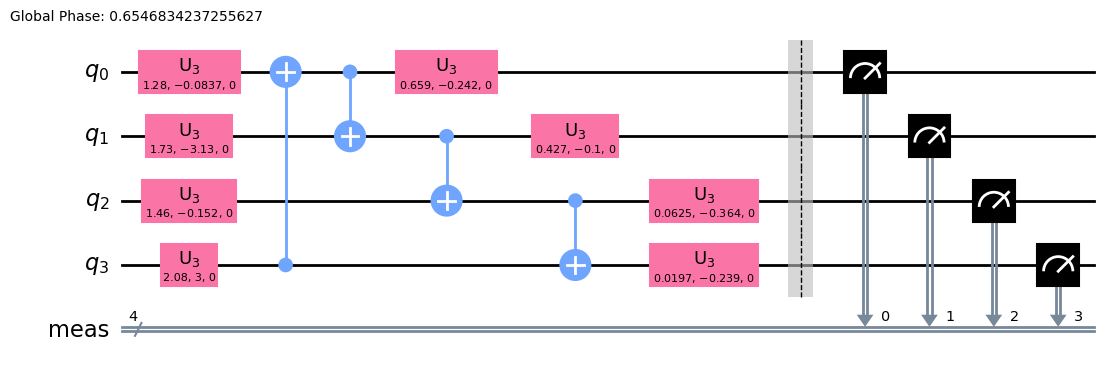

In [7]:
values = learning.params
bound_circuit = ansatz.assign_parameters(values)
bound_circuit.measure_all()

print()
transpiled_job = transpile(bound_circuit, backend, optimization_level=3)
print("Transpiled circuit:")
print(transpiled_job.draw('mpl', style="clifford"))
print()
print("Transpiled circuit gates:")
print(transpiled_job.count_ops())
print("Transpiled circuit number of parameters", transpiled_job.num_parameters)

<h3>Results</h3>

In [8]:
# Printing calculated ground state energy (final cost) and final circuit parameters
print(f"Iterations: {learning.costs_dictionary['iterations']} | Current cost: {learning.energy}")
print()
print(f'Calculated ground state energy: {learning.cost}')
print()
print(f'Calculated parameters: {learning.params}')

# Finding exact ground state energy
H_matrix = Operator(heisenberg_hamiltonian).data
eigenvalues = np.linalg.eigvalsh(H_matrix)
exact_ground_state = np.min(eigenvalues)
print()
print("Minimum eigenvalue (exact ground state):", exact_ground_state)
error = learning.cost-np.min(eigenvalues)
print(f"Error: {error}")

Iterations: 190 | Current cost: -2.68115234375

Calculated ground state energy: -2.68115234375

Calculated parameters: [ 1.27926054  1.4141159   1.45896393  1.06546985 -0.08374218  0.01152715
 -0.15207298 -0.1394021   0.65877646  0.42671336  0.06248415  0.01966006
 -0.24222632 -0.10024768 -0.36388084 -0.23932189]

Minimum eigenvalue (exact ground state): -3.0
Error: 0.31884765625


Calculating and printing the exact ground state energy through finding the minimum eigenvalue of the Hamiltonian:

<h3>Plotting energy convergence</h3>

Plotting the resulting convergence of energy to the ground state energy:

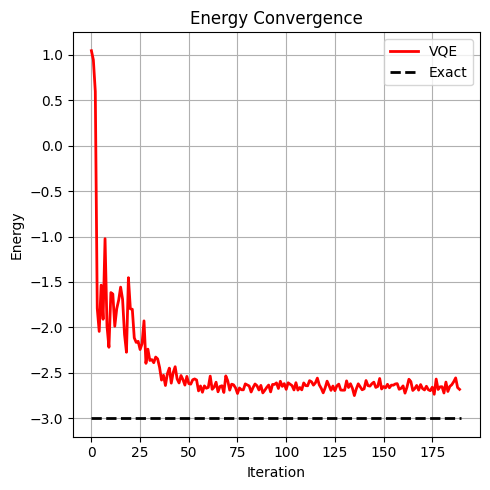

In [9]:
energies = learning.costs_dictionary["costs"]
num_iters = len(learning.costs_dictionary["costs"])

f1 = plt.figure(figsize=(5,5))
ax1 = f1.add_subplot(1, 1, 1)
plt.plot(energies, label='VQE', color = 'red', linewidth=2.0)
plt.hlines(exact_ground_state, xmin=0, xmax=round(num_iters), label='Exact', color='black', linestyles='dashed', linewidth=2.0)
plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.title("Energy Convergence")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

<h2>Results: Investigating magnetic order</h2>

The bitstrings of the state with all zeros $\ket{0000...}$ corresponds to all spins up, and the state with all ones corresponds to all spins down $\ket{1111...}$, and therefore correspond to ferromagnetic order. The Heisenberg model with $J > 0$ is ferromagnetic, so for positive $J$ the counts should reflect this, having most counts for these states.

On the other hand the state $\ket{010101...}$ corresponds to every other spin in the chain being up, and every other spin being down. The Heisenberg model for $J < 0$ is antiferromagnetic, so for negative $J$ most of the counts should be for this state and other states similar to it.

<h3>Defining function for getting counts and histograms</h3>

In [10]:
def get_counts_and_histogram(n, J, backend):
    circuit_transpiled = transpile(ansatz_function(n, J), target=backend.target, layout_method = "trivial", routing_method = "sabre", optimization_level=3)
    ansatz = remove_unused_qubits(circuit_transpiled)
    heisenberg_hamiltonian = heisenberg_sparse_pauli_op(n, J)
    hamiltonian = pad_hamiltonian(heisenberg_hamiltonian, ansatz.num_qubits)
    learning = Learning(ansatz, hamiltonian, backend, estimator, optimizer)
    result = learning.run()
    
    values = learning.params
    bound_circuit = ansatz.assign_parameters(values)
    bound_circuit.measure_all()

    transpiled_job = transpile(bound_circuit, backend)

    job = backend.run(transpiled_job, shots=1000)
    print()
    print("Counts:")
    print(job.result().get_counts())
    fig = plot_histogram(job.result().get_counts())
    fig.savefig("my_histogram.png")
    if J > 0:
        plt.title("Ferromagnetic order")
    if J < 0:
        plt.title("Antiferromagnetic order")
    plt.show()

<h3>Antiferromagnetic order without noise</h3>


Iterations: 1 | Current cost: 1.00244140625

Iterations: 2 | Current cost: 0.51416015625

Iterations: 3 | Current cost: 0.177734375

Iterations: 4 | Current cost: -0.31787109375

Iterations: 5 | Current cost: -0.3515625

Iterations: 6 | Current cost: -0.1083984375

Iterations: 7 | Current cost: -0.0439453125

Iterations: 8 | Current cost: -1.19873046875

Iterations: 9 | Current cost: -0.29296875

Iterations: 10 | Current cost: -1.4150390625

Iterations: 11 | Current cost: -1.94482421875

Iterations: 12 | Current cost: -0.98095703125

Iterations: 13 | Current cost: -1.93994140625

Iterations: 14 | Current cost: -2.2705078125

Iterations: 15 | Current cost: -1.41064453125

Iterations: 16 | Current cost: -2.2666015625

Iterations: 17 | Current cost: -1.35009765625

Iterations: 18 | Current cost: -1.962890625

Iterations: 19 | Current cost: -2.96435546875

Iterations: 20 | Current cost: -2.87158203125

Iterations: 21 | Current cost: -2.8291015625

Iterations: 22 | Current cost: -2.8369140

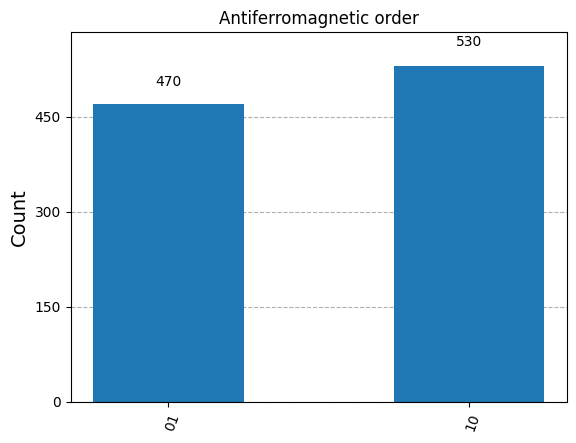

In [11]:
n = 2     # number of spins/qubits
J = -1.0   # coupling constant

backend = AerSimulator()

get_counts_and_histogram(n, J, backend)

<h3> Antiferromagnetic order with noise</h3>


Iterations: 1 | Current cost: 0.96240234375

Iterations: 2 | Current cost: 0.98095703125

Iterations: 3 | Current cost: 1.04541015625

Iterations: 4 | Current cost: 0.5439453125

Iterations: 5 | Current cost: 0.14208984375

Iterations: 6 | Current cost: 0.18798828125

Iterations: 7 | Current cost: 0.18798828125

Iterations: 8 | Current cost: -0.25439453125

Iterations: 9 | Current cost: -0.2744140625

Iterations: 10 | Current cost: -1.07421875

Iterations: 11 | Current cost: -1.15234375

Iterations: 12 | Current cost: -0.8330078125

Iterations: 13 | Current cost: -1.13330078125

Iterations: 14 | Current cost: -1.10791015625

Iterations: 15 | Current cost: -1.095703125

Iterations: 16 | Current cost: -1.40869140625

Iterations: 17 | Current cost: -1.16552734375

Iterations: 18 | Current cost: -1.90673828125

Iterations: 19 | Current cost: -1.87744140625

Iterations: 20 | Current cost: -1.74755859375

Iterations: 21 | Current cost: -1.4482421875

Iterations: 22 | Current cost: -1.880859

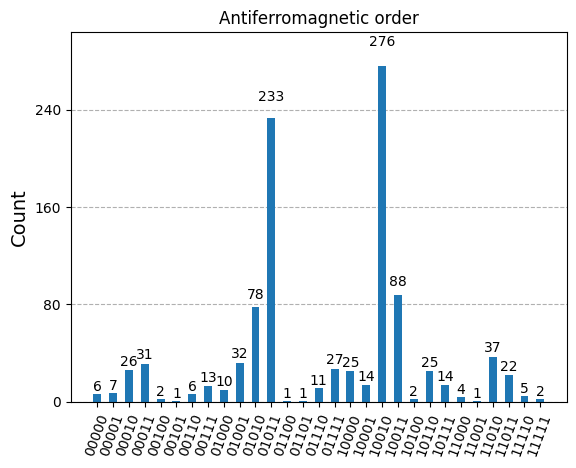

In [12]:
n = 4     # number of spins/qubits
J = -1.0   # coupling constant

backend = fake_aphrodite.IQMFakeAphrodite()

get_counts_and_histogram(n, J, backend)


Iterations: 1 | Current cost: 2.9580078125

Iterations: 2 | Current cost: 2.4755859375

Iterations: 3 | Current cost: 2.169921875

Iterations: 4 | Current cost: 1.47705078125

Iterations: 5 | Current cost: 0.5048828125

Iterations: 6 | Current cost: -0.1572265625

Iterations: 7 | Current cost: -0.23583984375

Iterations: 8 | Current cost: -0.67041015625

Iterations: 9 | Current cost: -0.640625

Iterations: 10 | Current cost: -1.078125

Iterations: 11 | Current cost: -1.21240234375

Iterations: 12 | Current cost: -1.29052734375

Iterations: 13 | Current cost: -0.96923828125

Iterations: 14 | Current cost: -0.42626953125

Iterations: 15 | Current cost: -0.541015625

Iterations: 16 | Current cost: -1.3779296875

Iterations: 17 | Current cost: -1.34130859375

Iterations: 18 | Current cost: -1.64990234375

Iterations: 19 | Current cost: -1.4873046875

Iterations: 20 | Current cost: -2.15283203125

Iterations: 21 | Current cost: -1.68896484375

Iterations: 22 | Current cost: -2.14453125

It

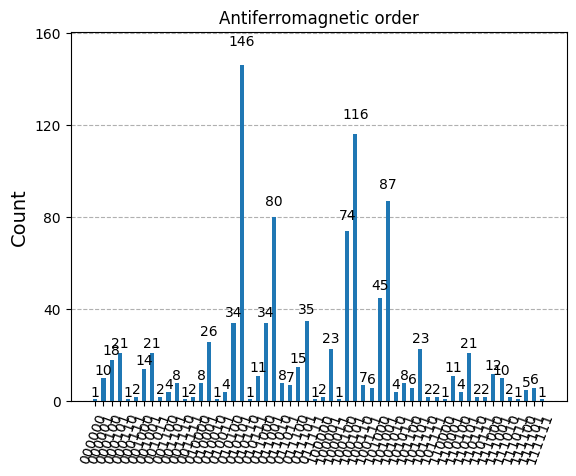

In [13]:
n = 5     # number of spins/qubits
J = -1.0   # coupling constant

get_counts_and_histogram(n, J, backend)

<h3>Ferromagnetic order without noise</h3>


Iterations: 1 | Current cost: 0.03271484375

Iterations: 2 | Current cost: 0.00048828125

Iterations: 3 | Current cost: -0.4326171875

Iterations: 4 | Current cost: -0.93798828125

Iterations: 5 | Current cost: -0.91796875

Iterations: 6 | Current cost: -1.087890625

Iterations: 7 | Current cost: -0.50390625

Iterations: 8 | Current cost: -0.92626953125

Iterations: 9 | Current cost: -0.90576171875

Iterations: 10 | Current cost: -1.0556640625

Iterations: 11 | Current cost: -0.49560546875

Iterations: 12 | Current cost: -0.390625

Iterations: 13 | Current cost: -1.34423828125

Iterations: 14 | Current cost: -1.451171875

Iterations: 15 | Current cost: -1.07177734375

Iterations: 16 | Current cost: -0.369140625

Iterations: 17 | Current cost: -1.1953125

Iterations: 18 | Current cost: -1.08935546875

Iterations: 19 | Current cost: -1.45751953125

Iterations: 20 | Current cost: -1.19384765625

Iterations: 21 | Current cost: -1.615234375

Iterations: 22 | Current cost: -1.00927734375

I

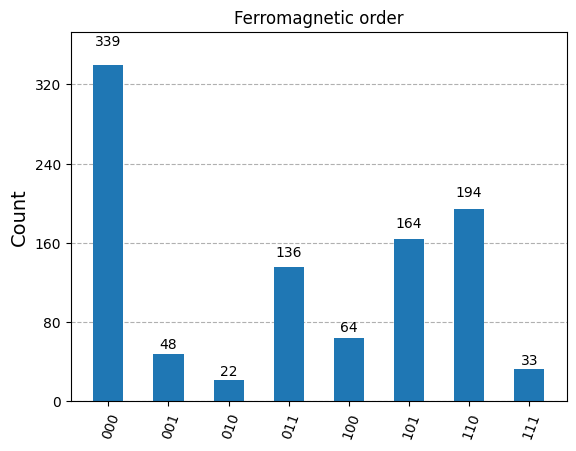

In [14]:
n = 3     # number of spins/qubits
J = 1.0  # coupling constant

backend = AerSimulator()

get_counts_and_histogram(n, J, backend)


Iterations: 1 | Current cost: -0.0126953125

Iterations: 2 | Current cost: 0.03759765625

Iterations: 3 | Current cost: -0.50244140625

Iterations: 4 | Current cost: -0.0341796875

Iterations: 5 | Current cost: -0.90869140625

Iterations: 6 | Current cost: -0.078125

Iterations: 7 | Current cost: -0.95263671875

Iterations: 8 | Current cost: -0.99267578125

Iterations: 9 | Current cost: -0.91064453125

Iterations: 10 | Current cost: -0.95263671875

Iterations: 11 | Current cost: -0.9091796875

Iterations: 12 | Current cost: -1.1865234375

Iterations: 13 | Current cost: -0.30810546875

Iterations: 14 | Current cost: -0.8017578125

Iterations: 15 | Current cost: -1.29248046875

Iterations: 16 | Current cost: -1.4462890625

Iterations: 17 | Current cost: -1.4228515625

Iterations: 18 | Current cost: -1.44921875

Iterations: 19 | Current cost: -1.4384765625

Iterations: 20 | Current cost: -0.78564453125

Iterations: 21 | Current cost: -0.8818359375

Iterations: 22 | Current cost: -1.42968

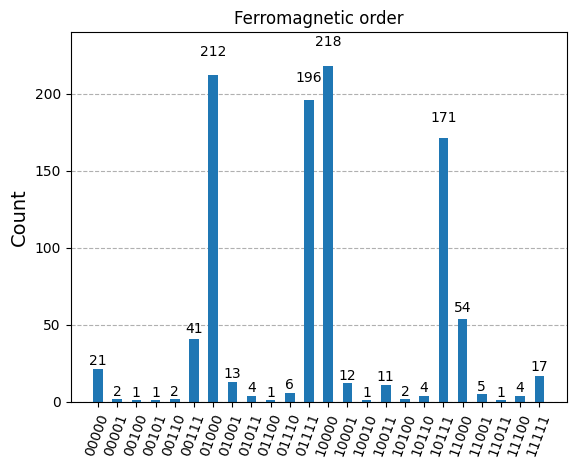

In [15]:
n = 5     # number of spins/qubits
J = 1.0  # coupling constant

backend = AerSimulator()

get_counts_and_histogram(n, J, backend)

<h2>References</h2>

[1]: N. Haboury. “Quantum magnetism”, 2022. Available: https://www.researchgate.net/publication/359011322_Quantum_magnetism.  [Accessed: Aug. 22, 2025]

[2]: M. Cerezo, A. Arrasmith, R. Babbush, et al. “Variational quantum algorithms”, Nat Rev Phys 3, pp. 625–644 (2021). doi: https://doi.org/10.1038/s42254-021-00348-9